# Dog, Cat & Panda Image Classifier

**AMV10 Visual Analytics — Group 14**

This notebook trains a ResNet-50 classifier on the Dog/Cat/Panda dataset
and exports all artefacts needed by the VA dashboard:
- `export.pkl` — fastai learner for LIME explanations
- `va_export/predictions.csv` — predictions for all images
- Model weights for retraining

Dataset: [Animal Image Dataset (Dog, Cat, Panda)](https://www.kaggle.com/datasets/ashishsaxena2209/animal-image-datasetdog-cat-and-panda)

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

Failed to read module file 'C:\Users\20211233\AppData\Local\Programs\Python\Python311\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\.venv-1\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\.venv-1\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\20211233\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1206, in _gcd_import
  File "<frozen importlib._bootstrap>", line

In [2]:
from fastai import *
from fastai.vision import *
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import json

In [3]:
def seed_everything(seed):
    import random
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

SEED = 42
seed_everything(SEED)
print('cudnn enabled:', torch.backends.cudnn.enabled)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

cudnn enabled: True
CUDA available: True
GPU: Quadro T1000 with Max-Q Design


## 1. Data Loading

The dataset has 3 folders: `dogs/`, `cats/`, `panda/`, each containing ~1000 images.
We build a DataFrame with image paths and labels (0=Cat, 1=Dog, 2=Panda).

In [4]:
# ── Adjust this path to where you extracted the dataset ─────────────
DATA_DIR = os.path.join('.', 'data')

CLASS_MAP = {'cats': 0, 'dogs': 1, 'panda': 2}
CLASS_NAMES = {0: 'Cat', 1: 'Dog', 2: 'Panda'}

rows = []
for folder, label in CLASS_MAP.items():
    folder_path = os.path.join(DATA_DIR, folder)
    if not os.path.isdir(folder_path):
        print(f'WARNING: {folder_path} not found')
        continue
    for fname in os.listdir(folder_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            rows.append({
                'image_id': os.path.splitext(fname)[0],
                'path': os.path.join(folder_path, fname),
                'label': label,
                'class_name': CLASS_NAMES[label],
            })

df = pd.DataFrame(rows)

# ── Create deterministic train/val/test split (60/20/20) ──────────────
# The test set is NEVER used during training — it's held out for the dashboard
np.random.seed(SEED)
rnd = np.random.rand(len(df))
df['split'] = 'train'
df.loc[(rnd >= 0.6) & (rnd < 0.8), 'split'] = 'val'
df.loc[rnd >= 0.8, 'split'] = 'test'

print(f'Total images: {len(df)}')
print(f'Split distribution:')
print(df['split'].value_counts())
print(f'\nClass distribution:')
print(df['class_name'].value_counts())


Total images: 3000
Split distribution:
split
train    1777
val       615
test      608
Name: count, dtype: int64

Class distribution:
class_name
Cat      1000
Dog      1000
Panda    1000
Name: count, dtype: int64


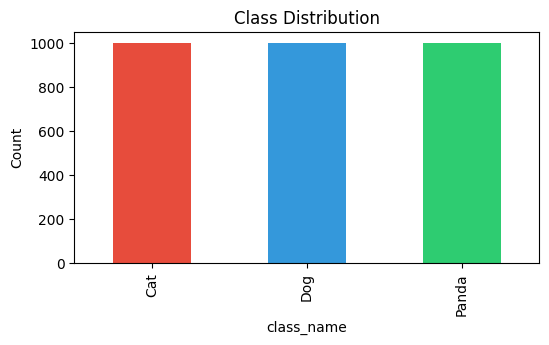

In [5]:
df['class_name'].value_counts().plot.bar(figsize=(6, 3), color=['#e74c3c', '#3498db', '#2ecc71'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

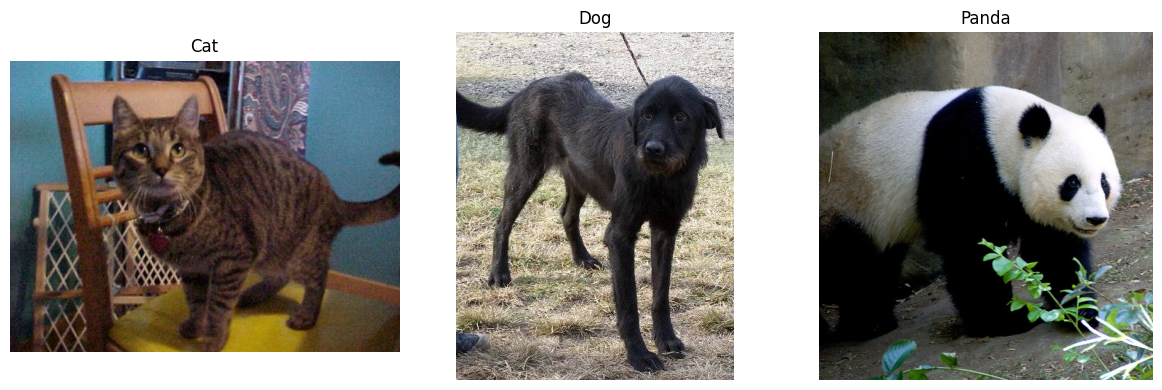

In [6]:
# Show sample images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, cls in enumerate(['cats', 'dogs', 'panda']):
    sample = df[df['class_name'] == CLASS_NAMES[CLASS_MAP[cls]]].iloc[0]
    from PIL import Image as PILImage
    img = PILImage.open(sample['path'])
    axes[i].imshow(img)
    axes[i].set_title(sample['class_name'])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 2. Create fastai DataBunch

We use fastai's ImageDataBunch with standard augmentations.
This is a **classification** task (not regression like DR grading).

In [7]:
bs = 64
sz = 224

# Train on train+val only (60+20=80%). Test set (20%) is held out.
train_val_df = df[df['split'].isin(['train', 'val'])].copy().reset_index(drop=True)
print(f'Training on {len(train_val_df)} images (train+val), holding out {len(df[df["split"]=="test"])} test images')

tfms = get_transforms(do_flip=True, flip_vert=False, max_rotate=15,
                       max_warp=0, max_zoom=1.1, max_lighting=0.2)

# Get positional indices of val rows within train_val_df
val_idx = train_val_df.index[train_val_df['split'] == 'val'].tolist()
print(f'Val indices: {len(val_idx)} images (positional range 0-{len(train_val_df)-1})')

data = (ImageList.from_df(df=train_val_df, path='', cols='path')
        .split_by_idx(val_idx)
        .label_from_df(cols='class_name')
        .transform(tfms, size=sz)
        .databunch(bs=bs)
        .normalize(imagenet_stats))

print(f'Train: {len(data.train_ds)}, Valid: {len(data.valid_ds)}')
print(f'Classes: {data.classes}')


Training on 2392 images (train+val), holding out 608 test images
Val indices: 615 images (positional range 0-2391)
Train: 1777, Valid: 615
Classes: ['Cat', 'Dog', 'Panda']


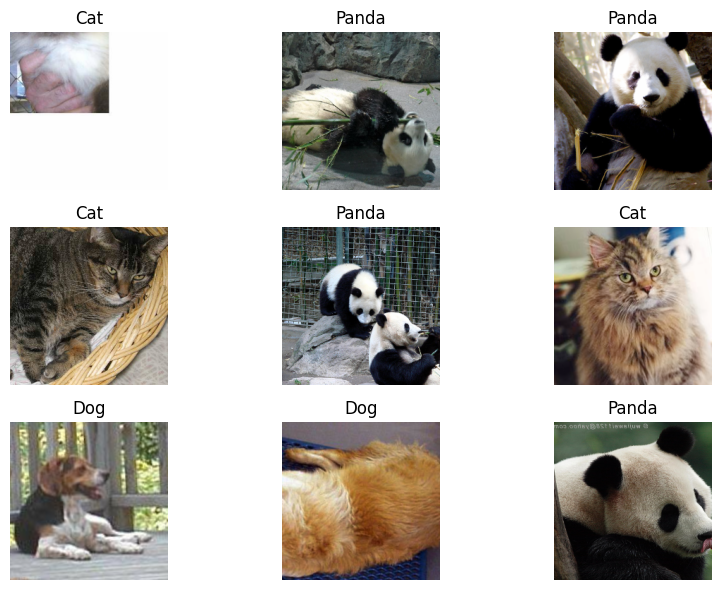

In [8]:
data.show_batch(rows=3, figsize=(9, 6))

## 3. Train ResNet-50

Transfer learning from ImageNet. This is a standard 3-class classification
with cross-entropy loss (fastai default for categorical labels).

In [9]:
learn = cnn_learner(data, base_arch=models.resnet50, metrics=[accuracy])

c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\.venv-1\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\.venv-1\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<div><div><progress max="4" value="3"></progress> 75.00% [3/4 11:46&lt;03:55]</div><div><table class="fastprogress"><thead><tr><th>epoch</th><th>train_loss</th><th>valid_loss</th><th>accuracy</th><th>time</th></tr></thead><tbody><tr><td>0</td><td>1.831507</td><td>#na#</td><td>05:06</td></tr><tr><td>1</td><td>0.952806</td><td>#na#</td><td>03:20</td></tr><tr><td>2</td><td>1.155749</td><td>#na#</td><td>03:19</td></tr><tr><td>3</td><td>2.803518</td><td>#na#</td><td>01:38</td></tr></tbody></table></div><div><progress max="27" value="3"></progress> 11.11% [3/27 01:31&lt;12:12... 2.0770]</div></div>

LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.
Min numerical gradient: 6.31E-07
Min loss divided by 10: 6.92E-03


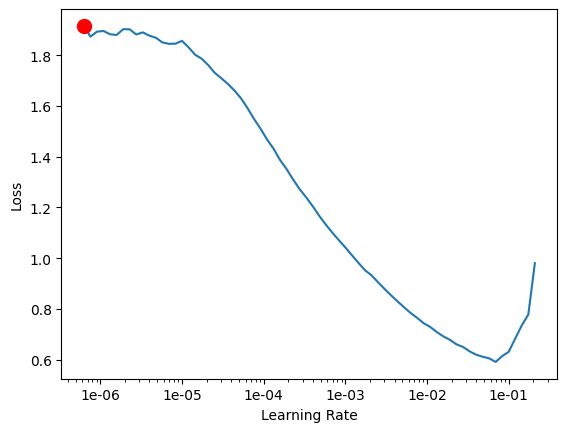

In [10]:
learn.lr_find()
learn.recorder.plot(suggestion=True)

In [11]:
learn.fit_one_cycle(4, max_lr=1e-2)

epoch,train_loss,valid_loss,accuracy,time
0,0.236819,1.036651,0.860163,04:55
1,0.225035,0.231965,0.956098,05:05
2,0.181347,0.150676,0.959350,05:12
3,0.129226,0.090612,0.973984,05:04


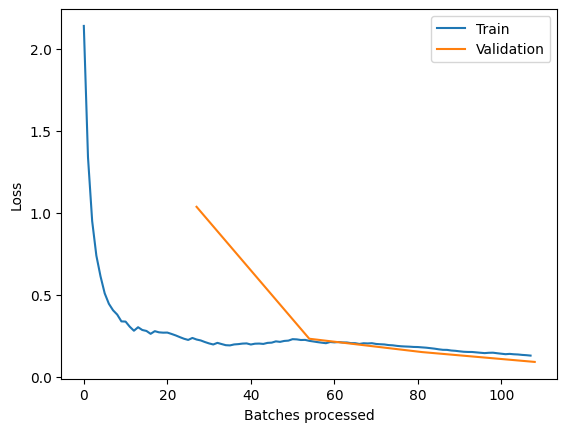

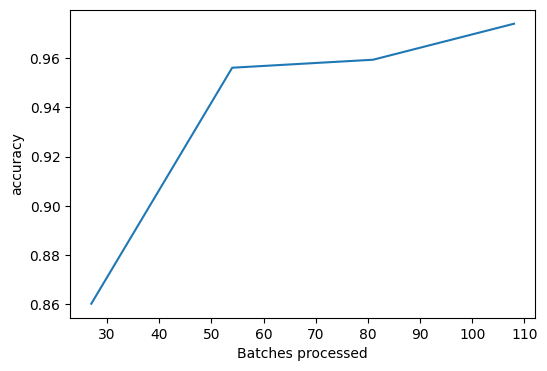

In [12]:
learn.recorder.plot_losses()
learn.recorder.plot_metrics()

<div><div><progress max="4" value="1"></progress> 25.00% [1/4 07:11&lt;21:35]</div><div><table class="fastprogress"><thead><tr><th>epoch</th><th>train_loss</th><th>valid_loss</th><th>accuracy</th><th>time</th></tr></thead><tbody><tr><td>0</td><td>0.036611</td><td>#na#</td><td>07:11</td></tr><tr><td>1</td><td>0.057216</td><td>#na#</td><td>03:29</td></tr></tbody></table></div><div><progress max="27" value="16"></progress> 59.26% [16/27 03:19&lt;02:17... 0.0530]</div></div>

LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.
Min numerical gradient: 1.58E-06
Min loss divided by 10: 1.00E-06


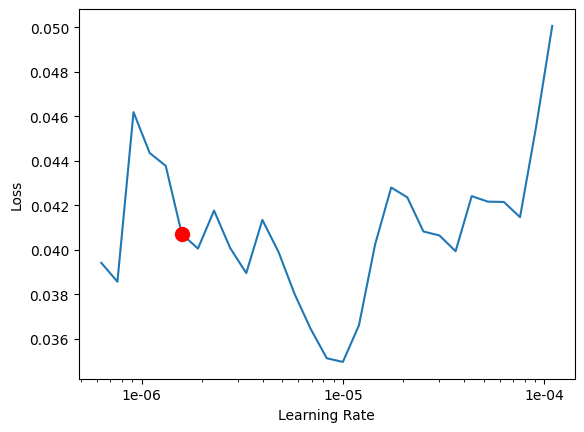

In [13]:
learn.unfreeze()
learn.lr_find()
learn.recorder.plot(suggestion=True)

In [14]:
learn.fit_one_cycle(6, max_lr=slice(1e-6, 1e-3))

epoch,train_loss,valid_loss,accuracy,time
0,0.051696,0.079087,0.973984,05:47
1,0.043637,0.068418,0.975610,05:48
2,0.043766,0.065668,0.980488,05:43
3,0.038329,0.085239,0.977236,05:40
4,0.031205,0.082621,0.970732,05:37
5,0.023755,0.077038,0.975610,05:49


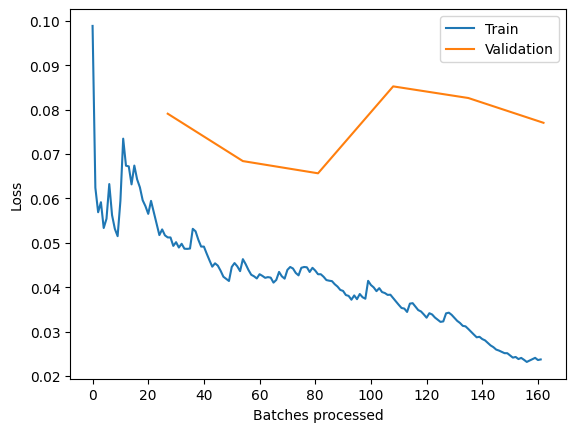

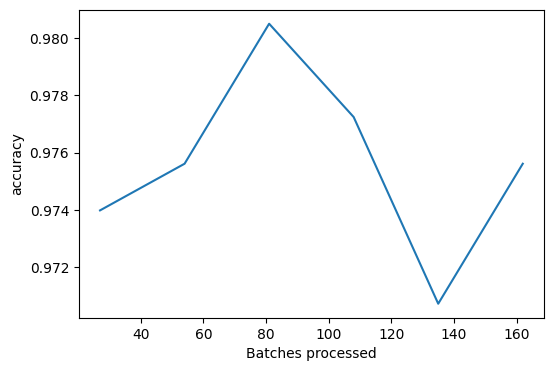

In [15]:
learn.recorder.plot_losses()
learn.recorder.plot_metrics()

In [16]:
# Save model
learn.export()
learn.save('stage-2')
print('Saved export.pkl and models/stage-2.pth')

Saved export.pkl and models/stage-2.pth


## 4. Evaluate

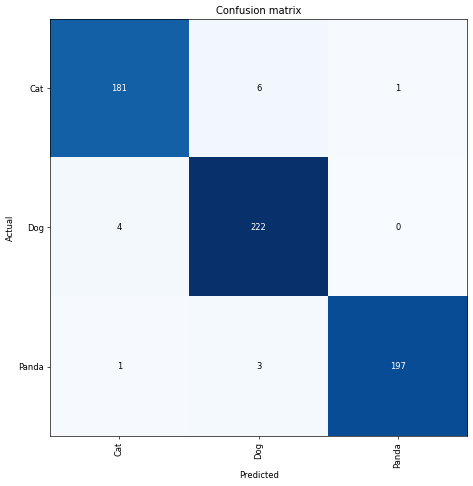

In [17]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(8, 8), dpi=60)

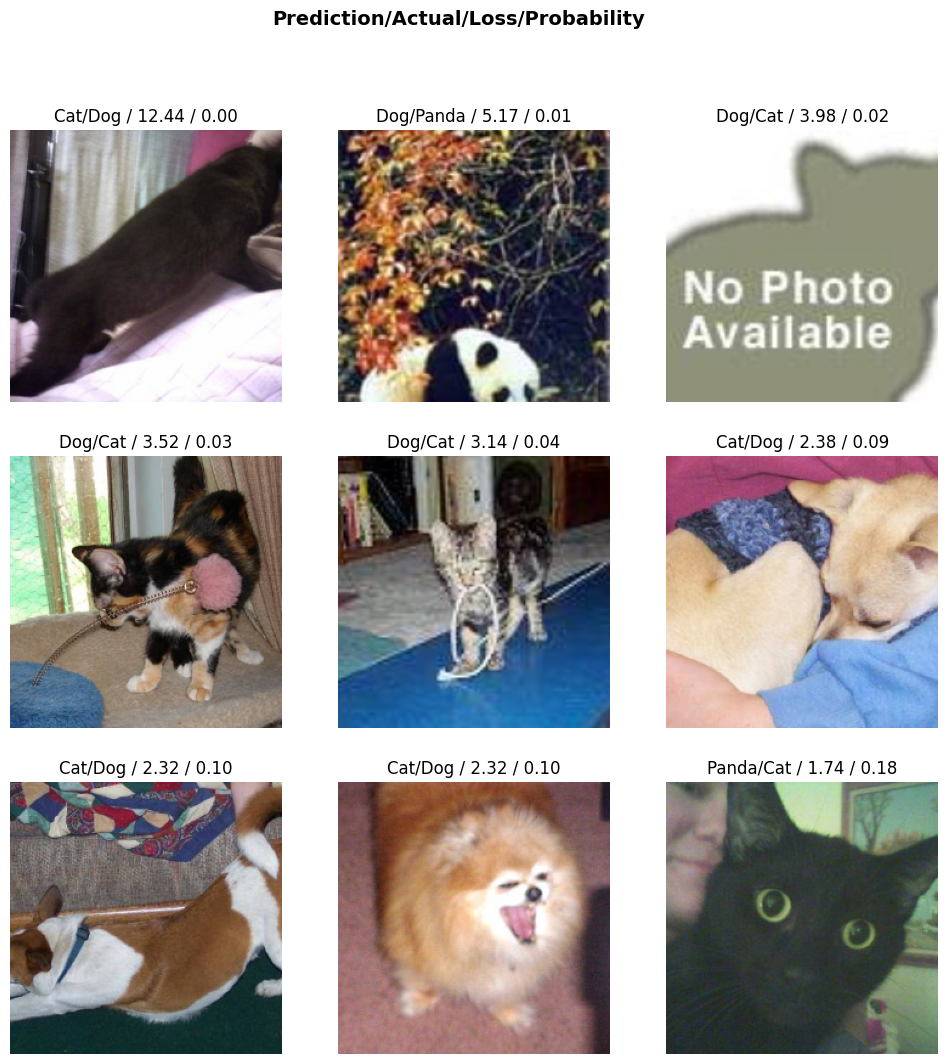

In [18]:
interp.plot_top_losses(9, figsize=(12, 12))

## 5. Export artefacts for VA dashboard

We need:
1. `predictions.csv` — image_id, true_class, pred_class, confidence, class_confidences
2. The model is used live by the dashboard (no separate embeddings file needed — hidden layers extracted on the fly)

In [19]:
EXPORT_DIR = os.path.join('.', 'va_export')
os.makedirs(EXPORT_DIR, exist_ok=True)

# ── Get predictions for ALL images (train + valid) ──────────────────
# We need to create a test set from ALL images to get predictions
all_image_list = ImageList.from_df(df=df, path='', cols='path')

# Add as test set and predict
learn.data.add_test(all_image_list)
preds, _ = learn.get_preds(ds_type=DatasetType.Test)

# preds is (N, 3) softmax probabilities
probs = preds.numpy()
pred_classes = probs.argmax(axis=1)

# Map fastai class indices to our labels
# fastai sorts class names alphabetically: Cat=0, Dog=1, Panda=2
fastai_classes = data.classes  # e.g. ['Cat', 'Dog', 'Panda']
print(f'fastai class order: {fastai_classes}')

# Build class name to our label mapping
name_to_label = {v: k for k, v in CLASS_NAMES.items()}
fastai_idx_to_label = [name_to_label[c] for c in fastai_classes]
print(f'fastai index → our label: {fastai_idx_to_label}')

fastai class order: ['Cat', 'Dog', 'Panda']
fastai index → our label: [0, 1, 2]


In [20]:
# Build predictions DataFrame with split info
id_to_split = dict(zip(df['image_id'], df['split']))

predictions = []
for i in range(len(df)):
    row = df.iloc[i]
    prob_vec = probs[i]  # probabilities in fastai class order
    pred_idx = pred_classes[i]
    pred_label = fastai_idx_to_label[pred_idx]
    
    # Reorder probs to our label order (0=Cat, 1=Dog, 2=Panda)
    ordered_probs = [float(prob_vec[fastai_classes.index(CLASS_NAMES[j])]) for j in range(3)]
    
    predictions.append({
        'image_id': row['image_id'],
        'true_class': int(row['label']),
        'pred_class': int(pred_label),
        'confidence': round(float(prob_vec.max()), 4),
        'class_confidences': json.dumps([round(p, 4) for p in ordered_probs]),
        'split': id_to_split[row['image_id']],
    })

pred_df = pd.DataFrame(predictions)

# Show accuracy per split
for s in ['train', 'val', 'test']:
    sdf = pred_df[pred_df['split'] == s]
    acc = (sdf['true_class'] == sdf['pred_class']).mean()
    print(f'{s:5s}: {len(sdf)} images, accuracy = {acc:.1%}')

print(f'\nOverall accuracy: {(pred_df["true_class"] == pred_df["pred_class"]).mean():.1%}')
pred_df.head()


train: 1777 images, accuracy = 99.9%
val  : 615 images, accuracy = 97.6%
test : 608 images, accuracy = 98.7%

Overall accuracy: 99.2%


,image_id,true_class,pred_class,confidence,class_confidences,split
0,cats_00001,0,0,1.0000,"[1.0, 0.0, 0.0]",train
1,cats_00002,0,0,1.0000,"[1.0, 0.0, 0.0]",test
2,cats_00003,0,0,1.0000,"[1.0, 0.0, 0.0]",val
3,cats_00004,0,0,1.0000,"[1.0, 0.0, 0.0]",train
4,cats_00005,0,0,0.9996,"[0.9996, 0.0003, 0.0]",train


In [21]:
# Save predictions
pred_df.to_csv(os.path.join(EXPORT_DIR, 'predictions.csv'), index=False)
print(f'Saved: {EXPORT_DIR}/predictions.csv ({len(pred_df)} rows)')

# Save class mapping
class_info = {
    'class_names': CLASS_NAMES,
    'fastai_classes': fastai_classes,
    'fastai_idx_to_label': fastai_idx_to_label,
    'num_classes': 3,
}
with open(os.path.join(EXPORT_DIR, 'class_info.json'), 'w') as f:
    json.dump(class_info, f, indent=2)
print(f'Saved: {EXPORT_DIR}/class_info.json')

Saved: .\va_export/predictions.csv (3000 rows)
Saved: .\va_export/class_info.json


In [22]:
print('\n=== Export Summary ===')
print(f'export.pkl          : model for LIME + dashboard')
print(f'va_export/predictions.csv : {len(pred_df)} predictions')
print(f'va_export/class_info.json : class mapping')
print(f'\nAccuracy: {(pred_df["true_class"] == pred_df["pred_class"]).mean():.1%}')
print(f'\nTo run the dashboard:')
print(f'  1. Copy export.pkl to the dashboard folder')
print(f'  2. Copy va_export/ to the dashboard folder')
print(f'  3. Make sure the images folder is accessible')
print(f'  4. python app_DCP.py')


=== Export Summary ===
export.pkl          : model for LIME + dashboard
va_export/predictions.csv : 3000 predictions
va_export/class_info.json : class mapping

Accuracy: 99.2%

To run the dashboard:
  1. Copy export.pkl to the dashboard folder
  2. Copy va_export/ to the dashboard folder
  3. Make sure the images folder is accessible
  4. python app_DCP.py
